train: (6818, 13) | test: (1705, 12)
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[117]	valid_0's rmse: 0.523487
Fold 1 RMSE (log scale): 0.5235
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[141]	valid_0's rmse: 0.515169
Fold 2 RMSE (log scale): 0.5152
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[106]	valid_0's rmse: 0.542658
Fold 3 RMSE (log scale): 0.5427
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[118]	valid_0's rmse: 0.523242
Fold 4 RMSE (log scale): 0.5232
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[121]	valid_0's rmse: 0.522581
Fold 5 RMSE (log scale): 0.5226

Overall CV RMSE (real sales scale): 1127.44

Feature importance:
                feature  importance
4         product_price         877
0     product_weight_kg  

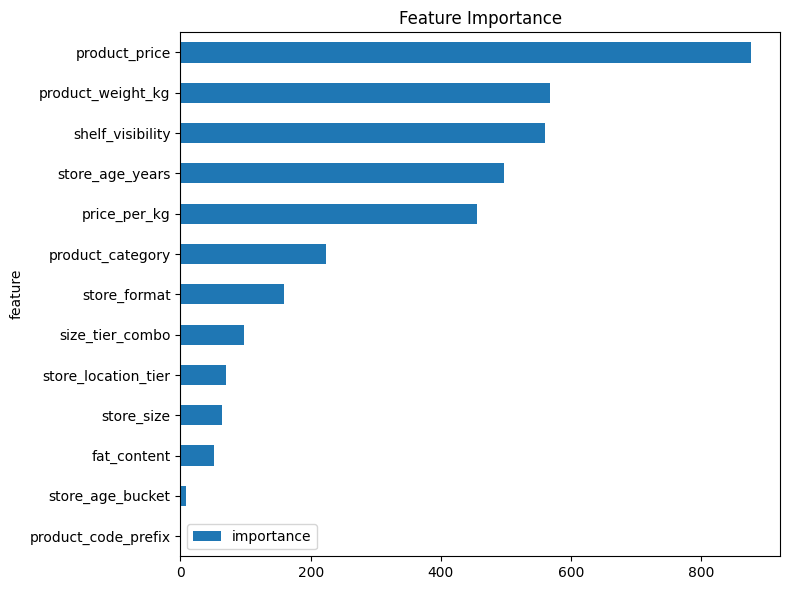


submission.csv saved. Shape: (1705, 2)


,id,total_sales
0,row_00009,2446.594652
1,row_00015,3579.323780
2,row_00019,2688.177150
3,row_00020,2910.903403
4,row_00023,2254.380078


In [1]:


# ============================================================
# 1. IMPORTS
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import LabelEncoder
import lightgbm as lgb

# ============================================================
# 2. LOAD DATA
# ============================================================
DATA_DIR = '/kaggle/input/competitions/dsn-bootcamp-qualification-hackathon-2026-ml-track'

train = pd.read_csv(f'{DATA_DIR}/train.csv')
test = pd.read_csv(f'{DATA_DIR}/test.csv')
sample_submission = pd.read_csv(f'{DATA_DIR}/sample_submission.csv')

print("train:", train.shape, "| test:", test.shape)

# ============================================================
# 3. COMBINE TRAIN + TEST FOR CONSISTENT CLEANING
# ============================================================
# We clean and engineer features on both datasets together so that,
# e.g., a category seen only in test still gets encoded consistently.
train['is_train'] = 1
test['is_train'] = 0
test['total_sales'] = np.nan  # test has no target - that's what we predict

full = pd.concat([train, test], axis=0, ignore_index=True)

# ============================================================
# 4. CLEAN TEXT COLUMNS (fix messy capitalization etc.)
# ============================================================
# product_category has inconsistent capitalization (the brief warns us).
full['product_category'] = full['product_category'].str.strip().str.title()

# fat_content: standardize any variants (Low Fat / low fat / LF etc.)
full['fat_content'] = full['fat_content'].str.strip().str.title()
full['fat_content'] = full['fat_content'].replace({
    'Lf': 'Low Fat', 'Low Fat': 'Low Fat', 'Reg': 'Regular', 'Regular': 'Regular'
})

# ============================================================
# 5. HANDLE MISSING VALUES
# ============================================================
# product_weight_kg is missing for some rows. The same product_code should
# always have the same weight, so fill using the product's own average first,
# then fall back to the overall median for anything still missing.
full['product_weight_kg'] = full.groupby('product_code')['product_weight_kg'] \
    .transform(lambda x: x.fillna(x.mean()))
full['product_weight_kg'] = full['product_weight_kg'].fillna(full['product_weight_kg'].median())

# store_size is missing for many rows. A given store_code should always have
# the same size, so fill using the most common size seen for that store.
store_size_map = full.dropna(subset=['store_size']).groupby('store_code')['store_size'] \
    .agg(lambda x: x.mode().iloc[0])
full['store_size'] = full['store_code'].map(store_size_map)
full['store_size'] = full['store_size'].fillna(full['store_size'].mode()[0])

# shelf_visibility has some suspicious 0.0 values (a sold product can't have
# literally 0 display space). Treat 0 as missing, then fill with the median
# visibility for that product's category.
full['shelf_visibility'] = full['shelf_visibility'].replace(0, np.nan)
full['shelf_visibility'] = full.groupby('product_category')['shelf_visibility'] \
    .transform(lambda x: x.fillna(x.median()))
full['shelf_visibility'] = full['shelf_visibility'].fillna(full['shelf_visibility'].median())

# ============================================================
# 6. FEATURE ENGINEERING
# ============================================================
# Price per kg - captures whether something is expensive for its weight
full['price_per_kg'] = full['product_price'] / full['product_weight_kg']

# Group store age into life-stage buckets - sales patterns often differ
# between brand-new stores and long-established ones, not just linearly.
full['store_age_bucket'] = pd.cut(
    full['store_age_years'], bins=[0, 10, 20, 30, 50],
    labels=['New', 'Growing', 'Established', 'Old']
)

# First two characters of product_code often denote a broad product family
# in retail datasets like this - worth testing as a feature.
full['product_code_prefix'] = full['product_code'].str[:2]

# Interaction: bigger, higher-tier stores likely behave differently than
# small stores in small towns.
full['size_tier_combo'] = full['store_size'].astype(str) + "_" + full['store_location_tier'].astype(str)

# ============================================================
# 7. ENCODE CATEGORICAL COLUMNS
# ============================================================
categorical_cols = [
    'fat_content', 'product_category', 'store_size', 'store_location_tier',
    'store_format', 'store_age_bucket', 'product_code_prefix', 'size_tier_combo'
]

encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    full[col] = le.fit_transform(full[col].astype(str))
    encoders[col] = le

# ============================================================
# 8. SPLIT BACK INTO TRAIN / TEST
# ============================================================
feature_cols = [
    'product_weight_kg', 'fat_content', 'shelf_visibility', 'product_category',
    'product_price', 'store_age_years', 'store_size', 'store_location_tier',
    'store_format', 'price_per_kg', 'store_age_bucket', 'product_code_prefix',
    'size_tier_combo'
]

train_clean = full[full['is_train'] == 1].copy()
test_clean = full[full['is_train'] == 0].copy()

X = train_clean[feature_cols]
y = train_clean['total_sales']
X_test = test_clean[feature_cols]

# Log-transform the target: total_sales is right-skewed (we saw this in the
# histogram). Predicting log(sales) and converting back tends to improve
# RMSE for this kind of skewed target.
y_log = np.log1p(y)

# ============================================================
# 9. CROSS-VALIDATED TRAINING (5-fold)
# ============================================================
# Instead of one train/validation split, we use 5-fold cross-validation:
# train on 4/5 of the data, validate on the remaining 1/5, repeat 5 times
# with a different fold held out each time. This gives a more reliable
# estimate of real performance than a single split.
kf = KFold(n_splits=5, shuffle=True, random_state=42)

oof_preds = np.zeros(len(X))          # out-of-fold predictions (for scoring)
test_preds = np.zeros(len(X_test))    # averaged predictions on the real test set

params = {
    'objective': 'regression',
    'metric': 'rmse',
    'learning_rate': 0.03,
    'num_leaves': 31,
    'max_depth': -1,
    'min_data_in_leaf': 20,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 1,
    'verbose': -1,
    'seed': 42
}

for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y_log.iloc[train_idx], y_log.iloc[val_idx]

    train_set = lgb.Dataset(X_tr, label=y_tr)
    val_set = lgb.Dataset(X_val, label=y_val, reference=train_set)

    model = lgb.train(
        params, train_set,
        num_boost_round=2000,
        valid_sets=[val_set],
        callbacks=[lgb.early_stopping(100), lgb.log_evaluation(0)]
    )

    oof_preds[val_idx] = model.predict(X_val, num_iteration=model.best_iteration)
    test_preds += model.predict(X_test, num_iteration=model.best_iteration) / kf.n_splits

    fold_rmse = np.sqrt(mean_squared_error(y_val, oof_preds[val_idx]))
    print(f"Fold {fold+1} RMSE (log scale): {fold_rmse:.4f}")

# Convert predictions back from log scale to real sales scale
oof_preds_real = np.expm1(oof_preds)
test_preds_real = np.expm1(test_preds)

overall_rmse = np.sqrt(mean_squared_error(y, oof_preds_real))
print(f"\nOverall CV RMSE (real sales scale): {overall_rmse:.2f}")

# ============================================================
# 10. FEATURE IMPORTANCE (helps you EXPLAIN your model - important!)
# ============================================================
importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': model.feature_importance()
}).sort_values('importance', ascending=False)

print("\nFeature importance:")
print(importance)

importance.plot(kind='barh', x='feature', y='importance', figsize=(8, 6))
plt.title('Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# ============================================================
# 11. GENERATE SUBMISSION FILE
# ============================================================
submission = sample_submission.copy()
submission['total_sales'] = test_preds_real
submission.to_csv('submission.csv', index=False)
print("\nsubmission.csv saved. Shape:", submission.shape)
submission.head()